In [ ]:
!pip install -q transformers datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.3 MB/s eta 0:00:00


In [ ]:
!pip install -q pytorch-lightning wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.4/840.4 kB 51.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 31.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 9.8 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

In [ ]:
from datasets import  DatasetDict
train_dataset = load_dataset("code_x_glue_ct_code_to_text", "ruby", split="train[:1000]")
test_dataset = load_dataset("code_x_glue_ct_code_to_text", "ruby", split="test[:2000]")
validation_dataset = load_dataset("code_x_glue_ct_code_to_text", "ruby", split="validation[:200]")

dataset = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})


print(dataset)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/24927 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1400 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1261 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'repo', 'path', 'func_name', 'original_string', 'language', 'code', 'code_tokens', 'docstring', 'docstring_tokens', 'sha', 'url'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['id', 'repo', 'path', 'func_name', 'original_string', 'language', 'code', 'code_tokens', 'docstring', 'docstring_tokens', 'sha', 'url'],
        num_rows: 200
    })
    test: Dataset({
        features: ['id', 'repo', 'path', 'func_name', 'original_string', 'language', 'code', 'code_tokens', 'docstring', 'docstring_tokens', 'sha', 'url'],
        num_rows: 1261
    })
})


In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("Salesforce/codet5-small")

prefix = "Summarize Ruby: "
max_input_length = 256
max_target_length = 128

def preprocess_examples(examples):
  codes = examples['code']
  docstrings = examples['docstring']

  inputs = [prefix + code for code in codes]
  model_inputs = tokenizer(inputs, max_length=max_input_length, padding="max_length", truncation=True)

  labels = tokenizer(docstrings, max_length=max_target_length, padding="max_length", truncation=True).input_ids
  labels_with_ignore_index = []
  for labels_example in labels:
    labels_example = [label if label != 0 else -100 for label in labels_example]
    labels_with_ignore_index.append(labels_example)

  model_inputs["labels"] = labels_with_ignore_index

  return model_inputs

tokenizer_config.json:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/703k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/294k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/12.5k [00:00<?, ?B/s]

In [ ]:
dataset = dataset.map(preprocess_examples, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1261 [00:00<?, ? examples/s]

In [ ]:
from torch.utils.data import DataLoader

dataset.set_format(type="torch", columns=['input_ids', 'attention_mask', 'labels'])
train_dataloader = DataLoader(dataset['train'], shuffle=True, batch_size=8)
valid_dataloader = DataLoader(dataset['validation'], batch_size=8)
test_dataloader = DataLoader(dataset['test'], batch_size=4)

In [ ]:
!pip install sacrebleu
import torch

In [ ]:
from transformers import T5ForConditionalGeneration, AdamW, get_linear_schedule_with_warmup
import pytorch_lightning as pl
import sacrebleu

class CodeT5(pl.LightningModule):
    def __init__(self, lr=5e-5, num_train_epochs=7, warmup_steps=300):
        super().__init__()
        self.model = T5ForConditionalGeneration.from_pretrained("Salesforce/codet5-small")
        self.save_hyperparameters()

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        return outputs

    def common_step(self, batch, batch_idx):
        outputs = self(**batch)
        loss = outputs.loss
        return loss, outputs.logits

    def training_step(self, batch, batch_idx):
        loss, logits = self.common_step(batch, batch_idx)
        labels = batch["labels"]
        preds = torch.argmax(logits, dim=-1)
        bleu = sacrebleu.corpus_bleu(preds, labels)
        self.log("training_loss", loss, on_epoch=True)
        self.log("training_bleu", bleu.score, on_epoch=True)
        return loss

    def prediction_step(self, batch, batch_idx):
        loss, logits = self.common_step(batch, batch_idx)
        labels = batch["labels"]
        preds = torch.argmax(logits, dim=-1)
        bleu = sacrebleu.corpus_bleu(preds, labels)
        print("training_bleu", bleu.score)
        print(preds,'/n',labels)

    def validation_step(self, batch, batch_idx):
        loss, logits = self.common_step(batch, batch_idx)
        labels = batch["labels"]
        preds = torch.argmax(logits, dim=-1)
        bleu = sacrebleu.corpus_bleu(preds, labels)
        self.log("validation_loss", loss, on_epoch=True)
        self.log("validation_bleu", bleu.score, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        loss, logits = self.common_step(batch, batch_idx)
        labels = batch["labels"]
        preds = torch.argmax(logits, dim=-1)
        bleu = sacrebleu.corpus_bleu(preds, labels)
        self.log("testing_loss", loss)
        self.log("testing_bleu", bleu.score)
        return loss

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr=self.hparams.lr)
        num_train_optimization_steps = self.hparams.num_train_epochs * len(train_dataloader)
        lr_scheduler = {'scheduler': get_linear_schedule_with_warmup(optimizer,
                                                    num_warmup_steps=self.hparams.warmup_steps,
                                                    num_training_steps=num_train_optimization_steps),
                        'name': 'learning_rate',
                        'interval':'step',
                        'frequency': 1}

        return {"optimizer": optimizer, "lr_scheduler": lr_scheduler}

    def train_dataloader(self):
        return train_dataloader

    def val_dataloader(self):
        return valid_dataloader

    def test_dataloader(self):
        return test_dataloader

In [ ]:
model = CodeT5()

config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [ ]:
trainer.validate(model)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      validation_loss      │     3.200697898864746     │
└───────────────────────────┴───────────────────────────┘

[{'validation_loss': 3.200697898864746}]

In [ ]:
trainer.test(model)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       testing_loss        │     3.415983200073242     │
└───────────────────────────┴───────────────────────────┘

[{'testing_loss': 3.415983200073242}]

{'learning_rate': [8.166666666666668e-06, 1.65e-05, 2.4833333333333335e-05, 3.316666666666667e-05, 4.15e-05, 4.9833333333333336e-05, 4.5739130434782614e-05, 4.1391304347826086e-05, 3.704347826086957e-05, 3.269565217391304e-05, 2.8347826086956525e-05, 2.4e-05, 1.965217391304348e-05, 1.5304347826086958e-05, 1.0956521739130435e-05]}


Text(0, 0.5, 'Learning Rate')

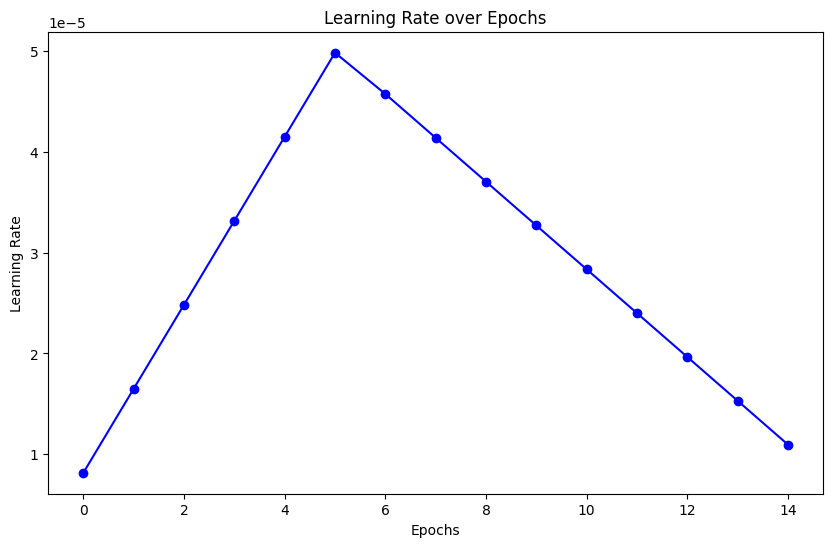

In [ ]:
import matplotlib.pyplot as plt
learning_rates = lr_monitor.lrs
learning_rates = lr_monitor.lrs
print(learning_rates)
plt.figure(figsize=(10, 6))
plt.plot([i for i in range(len(learning_rates['learning_rate']))], learning_rates['learning_rate'], marker='o', color='b', linestyle='-')
plt.title('Learning Rate over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')

In [ ]:
from transformers import AutoTokenizer
checkpoint = 'Salesforce/codet5-base'
tokenizer = AutoTokenizer.from_pretrained("Salesforce/codet5-small")

prefix = "Summarize Python: "
max_input_length = 256
max_target_length = 128

def preprocess_examples(examples):
  codes = examples['code']
  docstrings = examples['docstring']
  inputs = [prefix + code for code in codes]
  model_inputs = tokenizer(inputs,text_target = docstrings, max_length=max_input_length, padding="max_length", truncation=True)
  return model_inputs

from transformers import DataCollatorForSeq2Seq
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=checkpoint)

In [ ]:
dataset = dataset.map(preprocess_examples, batched=True)

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from torch.utils.data import DataLoader

dataset.set_format(type="torch", columns=['input_ids', 'attention_mask', 'labels'])
train_dataloader = DataLoader(dataset['train'], shuffle=True, batch_size=8)
test_dataloader = DataLoader(dataset['test'], batch_size=4)

In [ ]:
from transformers import T5ForConditionalGeneration, AdamW, get_linear_schedule_with_warmup
import pytorch_lightning as pl

class CodeT5(pl.LightningModule):
    def __init__(self, lr=5e-5, num_train_epochs=1, warmup_steps=200):
        super().__init__()
        self.model = T5ForConditionalGeneration.from_pretrained("Salesforce/codet5-small")
        self.save_hyperparameters()

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        return outputs

    def common_step(self, batch, batch_idx):
        outputs = self(**batch)
        loss = outputs.loss
        return loss

    def predict_step(self,  batch, batch_idx):
        loss = self.common_step(batch, batch_idx)
        self.log("precission_lost", loss)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self.common_step(batch, batch_idx)
        self.log("training_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.common_step(batch, batch_idx)
        self.log("validation_loss", loss, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        loss = self.common_step(batch, batch_idx)
        self.log("validation_loss", loss, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr=self.hparams.lr)
        num_train_optimization_steps = self.hparams.num_train_epochs * len(train_dataloader)
        lr_scheduler = {'scheduler': get_linear_schedule_with_warmup(optimizer,
                                                    num_warmup_steps=self.hparams.warmup_steps,
                                                    num_training_steps=num_train_optimization_steps),
                        'name': 'learning_rate',
                        'interval':'step',
                        'frequency': 1}

        return {"optimizer": optimizer, "lr_scheduler": lr_scheduler}

    def train_dataloader(self):
        return train_dataloader

    def val_dataloader(self):
        return valid_dataloader

    def test_dataloader(self):
        return test_dataloader

In [ ]:
model = CodeT5()

In [ ]:
from pytorch_lightning.callbacks import RichProgressBar
from pytorch_lightning.callbacks.progress.rich_progress import RichProgressBarTheme


progress_bar = RichProgressBar(
    theme=RichProgressBarTheme(
        description="green_yellow",
        progress_bar="green1",
        progress_bar_finished="green1",
        progress_bar_pulse="#6206E0",
        batch_progress="green_yellow",
        time="grey82",
        processing_speed="grey82",
        metrics="grey82",
    )
)

In [ ]:
import wandb

wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
new_model = 'my_t5_small_test'
model = model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint)
training_args = Seq2SeqTrainingArguments(
    output_dir=new_model,
    overwrite_output_dir=True,
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=6,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=2,
    predict_with_generate=True,
    fp16=True
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
trainer.validate(model)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      validation_loss      │    0.05505947768688202    │
└───────────────────────────┴───────────────────────────┘

[{'validation_loss': 0.05505947768688202}]